# MODULE 7 — Quality Benchmarking & Results (final, generalised)

**Project:** QVSC — Quantum-assisted Video Steganographic Communication

Y-channel DCT-QIM at coefficient (2,2), constant-QP intra-only H.264,
Reed–Solomon FEC + block interleaving, ChaCha20-Poly1305 AEAD payload,
non-blind extraction using transmitted sender masks.

---

### No hardcoded measurements

Every quantity in this notebook is **derived at runtime** from the loaded
artifacts. Nothing is copied from a previous run's console output. Change
the message, the RS parity, the cover video, or the key, and every table,
figure, and threshold follows automatically.

Section 5b recovers the pre-FEC lengths by decoding the payload itself:
`fec_encode()` stores a 4-byte length header *inside* the RS protection,
so decoding a clean payload returns the AEAD blob exactly. Arithmetic
shortcuts such as `ncw*RS_K - 4` are upper bounds only, because
`fec_encode` zero-pads to a codeword boundary and the padding amount is
not recoverable from the length alone. Decoding was verified exact at
parity 16/32/64/96 and payloads from 1 KB to 200 KB.

### Changes from the v3 notebook

| # | Change | Reason |
|---|--------|--------|
| 1 | Capacity summed over all frames | v3 used frame 0 × frame count. Frame 0 is an outlier (fewest ROI blocks in the clip), understating capacity ~37×, which drew the payload *above* the capacity curve — self-refuting, since the payload embeds successfully. |
| 2 | Post-compression PSNR/SSIM added | v3 measured cover-vs-stego only, so "imperceptibility vs compression" was flat by construction. |
| 3 | FEC threshold converted to the bit domain | v3 compared bit BER against a *byte* budget (t/N). Correct cliff is 1−(1−t/N)^(1/8). |
| 4 | Codeword count from payload length | `ceil((len+4)/RS_K)` assumed a pre-FEC input; the loaded blob is post-FEC. |
| 5 | Ablation B computed in log space | `(1−p)**n` underflows float64 to exactly 0.0, printing `0.000e+00` on every row. |
| 6 | Steganalysis uses a grouped split | A random split can put a frame's cover in train and its stego in test. |
| 7 | `byte_exact` → `channel_bit_exact_pre_fec` | The old name read as "payload recovered exactly"; it means the channel was clean *before* FEC, hence `False` on every passing row. |
| 8 | `detect_roi_blocks` vectorised | Identical output, ~2× faster (50→25 ms/frame at 1080p). Canny and dilate dominate, so this is a minor win. The real gain is `block_edge_density`, which lets Section 11 threshold one array six times instead of running Canny six times per frame. |
| 9 | Steganalysis, ablations, side-information cost | Absent from v3; the first two are the gaps reviewers name. |
| 10 | 300 dpi, author name removed | IEEE print quality; double-blind submission. |

**Runtime:** §1–12 ≈ 40 min · §13–14 ≈ 35 min · §15 optional.

## Section 1 — Imports

In [1]:
import cv2
import numpy as np
from scipy.fft import dctn, idctn
from scipy.stats import binom, entropy
import matplotlib.pyplot as plt
import pandas as pd
import os
import math
import gzip
import lzma
import subprocess
import time
from Crypto.Cipher import ChaCha20_Poly1305
import fec_module as fec

plt.rcParams['figure.dpi']  = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size']   = 11
np.set_printoptions(suppress=True, precision=4)

print(f"FEC module: RS({fec.RS_N},{fec.RS_K}), parity={fec.RS_PARITY}")
print("Libraries imported.")

FEC module: RS(255,191), parity=64
Libraries imported.


## Section 2 — Configuration

Constant **QP**, not CRF. CRF is rate-controlled: the quantiser varies
frame to frame, which destroyed the embedded coefficient on every frame
after the first. Constant QP quantises every frame identically, so the
payload degrades uniformly — and QP is the correct controlled variable
for a robustness study.

| QP | Quality | Use case |
|----|---------|----------|
| 18 | Near-lossless | Archival |
| 23 | High (baseline) | Standard |
| 28 | Moderate | Lower bandwidth |
| 35 | Heavy | Stress test |

In [2]:
# ── Inputs from previous modules ─────────────────────────────────────
COVER_VIDEO_PATH = 'cover_video.mp4'
ROI_MASKS_FILE   = 'roi_masks.npy'
CIPHERTEXT_FILE  = 'fec_payload.bin'      # FEC-protected, from Module 2
KEY_FILE         = 'quantum_key.bin'

M4_META_FILE   = 'embedding_metadata.npy'
M5_REPORT_FILE = 'extraction_report.npy'
M6_REPORT_FILE = 'decryption_report.npy'

# ── Outputs ──────────────────────────────────────────────────────────
RESULTS_CSV      = 'benchmark_results.csv'
RESULTS_NPY      = 'benchmark_results.npy'
FIG_PSNR_SSIM    = 'figure_psnr_ssim.png'
FIG_BER_VS_QP    = 'figure_ber_vs_qp.png'
FIG_CAPACITY     = 'figure_capacity.png'
FIG_QUALITY_GRID = 'figure_quality_grid.png'
FIG_DELTA_SWEEP  = 'figure_delta_sweep.png'
FIG_MASK_AGREE   = 'figure_mask_agreement.png'
FIG_FEC_HEADROOM = 'figure_fec_headroom.png'
FIG_STEGANALYSIS = 'figure_steganalysis.png'

# ── Pipeline parameters (must match Module 4) ────────────────────────
BLOCK_SIZE     = 8
COEFF_POS      = (2, 2)        # low-frequency, compression-resilient
QIM_DELTA      = 50
EMBED_CHANNEL  = 0             # Y (luminance)
MAX_EMBED_ITER = 15
INTRA_ONLY     = True
H264_PRESET    = 'medium'
AAD            = b"QVSC-Module2"
EDGE_THRESHOLD = 0.30

# ── AEAD framing from Module 2: [nonce][ciphertext][tag] ─────────────
NONCE_LEN = 12
TAG_LEN   = 16

# ── Sweep ────────────────────────────────────────────────────────────
QP_VALUES      = [18, 23, 28, 35]
DELTA_SWEEP    = [30, 40, 50, 60, 70]
BASELINE_QP    = 23            # operating point for ablations/steganalysis
RUN_FULL_SWEEP = True
RUN_MULTIVIDEO = False         # Section 15 — needs extra clips

print("=" * 70)
print("  MODULE 7 CONFIGURATION")
print("=" * 70)
print(f"  QP values:      {QP_VALUES}   (baseline {BASELINE_QP})")
print(f"  Delta values:   {DELTA_SWEEP}")
print(f"  Embedding:      Delta={QIM_DELTA}, coeff={COEFF_POS}, "
      f"block={BLOCK_SIZE}, channel={EMBED_CHANNEL}")
print(f"  Full sweep:     {RUN_FULL_SWEEP}")
print(f"  Multi-video:    {RUN_MULTIVIDEO}")
print("=" * 70)

  MODULE 7 CONFIGURATION
  QP values:      [18, 23, 28, 35]   (baseline 23)
  Delta values:   [30, 40, 50, 60, 70]
  Embedding:      Delta=50, coeff=(2, 2), block=8, channel=0
  Full sweep:     True
  Multi-video:    False


## Section 3 — Consolidated pipeline functions

Re-defined inline so this notebook is self-contained. Bodies are
identical to Modules 3–6 **except** `detect_roi_blocks`, which is
vectorised — see its docstring for why the output is unchanged.

In [3]:
# ── Module 3: ROI detection ──────────────────────────────────────────
def block_edge_density(frame_bgr, block_size=8, canny_low=50, canny_high=150,
                       blur_sigma=1.0, dilate_iterations=2):
    """Per-block dilated-edge density, as a (blocks_y, blocks_x) float array.

    Split out from detect_roi_blocks() because the density does not depend
    on the threshold: the capacity sweep computes it once per frame and
    thresholds it six times, instead of running Canny six times per frame.
    That is where the real speedup lives (~2.1 min -> ~0.2 min).
    """
    ycrcb     = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    y_blurred = cv2.GaussianBlur(ycrcb[:, :, 0], (5, 5), blur_sigma)
    edges     = cv2.Canny(y_blurred, canny_low, canny_high)
    kernel    = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    ed        = cv2.dilate(edges, kernel, iterations=dilate_iterations)

    h, w   = ed.shape
    by, bx = h // block_size, w // block_size
    tiles  = (ed[:by * block_size, :bx * block_size] > 0).reshape(
        by, block_size, bx, block_size)
    return tiles.mean(axis=(1, 3))


def detect_roi_blocks(frame_bgr, block_size=8, canny_low=50, canny_high=150,
                      blur_sigma=1.0, dilate_iterations=2,
                      edge_threshold=0.30):
    """Block-level ROI mask. Output is bit-identical to the Module 3/5 loop.

    The original body iterated every block in Python and tested
    np.count_nonzero(block)/64 > threshold. Here that quantity is the mean
    of a boolean array over the two intra-block axes, computed for all
    blocks at once. n/64 for integer n is exactly representable in float64,
    so the comparison is identical rather than merely close (verified by
    np.array_equal against the loop version on textured 1080p frames).

    Measured 50 -> 25 ms/frame at 1080p, i.e. ~2x. The Python loop was not
    the bottleneck it appeared to be; Canny and dilate dominate.
    """
    return (block_edge_density(frame_bgr, block_size, canny_low, canny_high,
                               blur_sigma, dilate_iterations)
            > edge_threshold).astype(np.uint8)


# ── Module 4: DCT / QIM core ─────────────────────────────────────────
def apply_dct_2d(block):
    return dctn(block, type=2, norm='ortho')

def apply_idct_2d(dct_block):
    return idctn(dct_block, type=2, norm='ortho')

def qim_embed_bit(coeff, bit, delta):
    quantized = delta * np.round(coeff / delta)
    return quantized + ((-1) ** (1 - bit)) * (delta / 4)

def qim_extract_bit(coeff, delta):
    quantized = delta * np.round(coeff / delta)
    return 1 if (coeff - quantized) > 0 else 0

print("ROI + DCT/QIM functions defined.")

ROI + DCT/QIM functions defined.


In [4]:
# ── Module 4: informed single-frame embed / extract (Y channel) ──────
def embed_in_frame(frame_bgr, block_mask, payload_bits, bit_index,
                   block_size=8, coeff_pos=(2, 2), delta=50, channel=0,
                   max_iter=15):
    """Informed DCT-QIM embedding. After embedding, simulate the
    YCrCb<->BGR<->uint8 round-trip the extractor sees, find blocks that
    decode wrong, and pre-distort them until every block reads back
    correctly. Drives pre-compression BER to 0% — essential, because a
    single residual bit destroys the Poly1305 tag."""
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    chan  = ycrcb[:, :, channel].astype(np.float64)
    by_n, bx_n = block_mask.shape
    u, v = coeff_pos
    asg = []
    for by in range(by_n):
        for bx in range(bx_n):
            if bit_index >= len(payload_bits): break
            if block_mask[by, bx] == 0: continue
            y0, x0 = by * block_size, bx * block_size
            D = apply_dct_2d(chan[y0:y0+block_size, x0:x0+block_size])
            b = int(payload_bits[bit_index])
            D[u, v] = qim_embed_bit(D[u, v], b, delta)
            chan[y0:y0+block_size, x0:x0+block_size] = np.clip(apply_idct_2d(D), 0, 255)
            asg.append((y0, x0, b)); bit_index += 1
        if bit_index >= len(payload_bits): break
    for _ in range(max_iter):
        ycrcb[:, :, channel] = np.round(np.clip(chan, 0, 255)).astype(np.uint8)
        rt = cv2.cvtColor(cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR),
                          cv2.COLOR_BGR2YCrCb)[:, :, channel].astype(np.float64)
        wrong = [(y0, x0, b) for (y0, x0, b) in asg
                 if qim_extract_bit(
                     apply_dct_2d(rt[y0:y0+block_size, x0:x0+block_size])[u, v],
                     delta) != b]
        if not wrong: break
        for (y0, x0, b) in wrong:
            obs = apply_dct_2d(rt[y0:y0+block_size, x0:x0+block_size])[u, v]
            q = delta * np.round(obs / delta)
            correct = q + (1 if b else -1) * (delta / 4)
            Dw = apply_dct_2d(chan[y0:y0+block_size, x0:x0+block_size])
            Dw[u, v] += (correct - obs)
            chan[y0:y0+block_size, x0:x0+block_size] = np.clip(apply_idct_2d(Dw), 0, 255)
    ycrcb[:, :, channel] = np.round(np.clip(chan, 0, 255)).astype(np.uint8)
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR), bit_index, len(asg)


def extract_from_frame(frame_bgr, block_mask, num_bits_to_extract,
                       block_size=8, coeff_pos=(2, 2), delta=50, channel=0):
    chan = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)[:, :, channel].astype(np.float64)
    by_n, bx_n = block_mask.shape
    out = []; u, v = coeff_pos
    for by in range(by_n):
        for bx in range(bx_n):
            if len(out) >= num_bits_to_extract: break
            if block_mask[by, bx] == 0: continue
            y0, x0 = by * block_size, bx * block_size
            out.append(qim_extract_bit(
                apply_dct_2d(chan[y0:y0+block_size, x0:x0+block_size])[u, v], delta))
        if len(out) >= num_bits_to_extract: break
    return out


def extract_video_frames(video_path, max_frames=None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames, count = [], 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame); count += 1
        if max_frames and count >= max_frames: break
    cap.release()
    return frames, fps, width, height


def write_lossless_avi(frames, path, fps):
    """MJPG intermediate. fps is carried through rather than assumed: it
    does not affect pixel data (frames are indexed, not timed) but a wrong
    value would propagate into any downstream timing analysis."""
    fh, fw = frames[0].shape[:2]
    wr = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'MJPG'),
                         float(fps) if fps and fps > 0 else 30.0, (fw, fh))
    for f in frames:
        wr.write(f)
    wr.release()
    return os.path.exists(path) and os.path.getsize(path) > 0

print("Embed / extract / video I/O defined.")

Embed / extract / video I/O defined.


In [5]:
# ── Quality metrics, crypto, bit utilities, compressor ───────────────
from skimage.metrics import structural_similarity as _ssim

def calculate_psnr(original, modified):
    """Peak Signal-to-Noise Ratio in dB. Higher = less distortion."""
    mse = np.mean((original.astype(np.float64) - modified.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0 ** 2 / mse)


def calculate_ssim(original, modified):
    """Windowed SSIM (11x11 Gaussian, averaged) on full colour."""
    return float(_ssim(original, modified, channel_axis=2, data_range=255))


def decrypt_chacha20_poly1305(key, nonce, ciphertext, tag, aad=b"QVSC-Module2"):
    cipher = ChaCha20_Poly1305.new(key=key, nonce=nonce)
    cipher.update(aad)
    return cipher.decrypt_and_verify(ciphertext, tag)


def bytes_to_bits(byte_data):
    bits = []
    for byte in byte_data:
        for bit_pos in range(7, -1, -1):
            bits.append((byte >> bit_pos) & 1)
    return np.array(bits, dtype=np.uint8)


def bits_to_bytes(bits):
    bits = np.asarray(bits, dtype=np.uint8)
    pad = (-len(bits)) % 8
    if pad:
        bits = np.concatenate([bits, np.zeros(pad, dtype=np.uint8)])
    weights = np.array([128, 64, 32, 16, 8, 4, 2, 1], dtype=np.uint8)
    return bytes(np.sum(bits.reshape(-1, 8) * weights, axis=1).astype(np.uint8))


def compress_h264_ffmpeg(input_path, output_path, qp=23, preset='medium',
                         intra_only=True):
    """Constant-QP H.264, identical invocation to Module 4. Returns
    (ok, stderr) so a sweep failure is diagnosable instead of silent."""
    cmd = ['ffmpeg', '-y', '-loglevel', 'error', '-i', input_path,
           '-c:v', 'libx264', '-qp', str(qp), '-preset', preset,
           '-pix_fmt', 'yuv420p']
    if intra_only:
        cmd += ['-x264-params', 'keyint=1:scenecut=0']
    cmd += [output_path]
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=1200)
        if r.returncode == 0:
            return True, None
        return False, (r.stderr or '').strip()[-600:]
    except FileNotFoundError:
        return False, "ffmpeg not found on PATH"
    except subprocess.TimeoutExpired:
        return False, "ffmpeg timed out (>1200s)"

print("Metrics / crypto / utilities defined.")

Metrics / crypto / utilities defined.


## Section 4 — Single-run pipeline wrapper

One full sender→receiver cycle at a given (QP, Δ).

Extraction uses the **sender's** masks. Receiver-regenerated masks are
computed only as a drift diagnostic: even 2–3% block drift desynchronises
the sequential bit stream and yields ~50% BER, which no FEC can repair.
That is why the masks are transmitted as side information — and why
Section 12b measures what that costs.

In [6]:
def run_pipeline_once(cover_frames, roi_masks, payload_bits, ciphertext_blob,
                      key, qp, delta=50, coeff_pos=(2, 2), block_size=8,
                      preset='medium', fps=30.0, edge_threshold=0.30,
                      verbose=False):
    """Execute one full QVSC pipeline run and return all measured metrics."""
    t_start = time.time()

    def _fail(tag, stderr=None, **extra):
        return {'qp': qp, 'delta': delta,
                'avg_psnr': extra.get('avg_psnr'), 'avg_ssim': extra.get('avg_ssim'),
                'post_psnr': None, 'post_ssim': None,
                'pre_ber': extra.get('pre_ber'), 'post_ber': None,
                'mask_agreement': None, 'fec_fails': None,
                'channel_bit_exact_pre_fec': None,
                'decryption_ok': False, 'decryption_err': None,
                'compressed_kb': None, 'error': tag, 'ffmpeg_stderr': stderr,
                'elapsed_s': time.time() - t_start}

    # ── 1. Embed ─────────────────────────────────────────────────────
    stego_frames, bits_per_frame = [], []
    psnr_list, ssim_list = [], []
    bit_index = 0
    for i, frame in enumerate(cover_frames):
        if bit_index >= len(payload_bits):
            stego_frames.append(frame.copy()); bits_per_frame.append(0); continue
        stego, bit_index, n_bits = embed_in_frame(
            frame, roi_masks[i], payload_bits, bit_index,
            block_size, coeff_pos, delta)
        stego_frames.append(stego); bits_per_frame.append(n_bits)
        if n_bits > 0:
            psnr_list.append(calculate_psnr(frame, stego))
            ssim_list.append(calculate_ssim(frame, stego))

    if bit_index < len(payload_bits):
        return _fail('insufficient_capacity')

    avg_psnr = float(np.mean(psnr_list)) if psnr_list else float('inf')
    avg_ssim = float(np.mean(ssim_list)) if ssim_list else 1.0

    # ── 2. Pre-compression BER (informed embedding should give exactly 0) ─
    pre_bits, bits_left = [], len(payload_bits)
    for i, sf in enumerate(stego_frames):
        if bits_left <= 0: break
        if bits_per_frame[i] == 0: continue
        ext = extract_from_frame(sf, roi_masks[i], bits_per_frame[i],
                                 block_size, coeff_pos, delta)
        pre_bits.extend(ext); bits_left -= len(ext)
    pre_bits = np.array(pre_bits, dtype=np.uint8)
    pre_ber = (int(np.sum(pre_bits != payload_bits[:len(pre_bits)]))
               / len(pre_bits) * 100) if len(pre_bits) else 100.0

    # ── 3. Write raw stego video ─────────────────────────────────────
    #  Relative paths in the CWD, where every other artifact lives.
    #  '/tmp' is POSIX-only and broke on Windows.
    raw_path  = f'_bench_raw_qp{qp}_d{delta}.avi'
    comp_path = f'_bench_comp_qp{qp}_d{delta}.mp4'
    if not write_lossless_avi(stego_frames, raw_path, fps):
        return _fail('raw_writer_failed', 'VideoWriter produced no file',
                     avg_psnr=avg_psnr, avg_ssim=avg_ssim, pre_ber=pre_ber)

    # ── 4. H.264 compression (constant QP) ───────────────────────────
    ok, ffmpeg_stderr = compress_h264_ffmpeg(raw_path, comp_path, qp=qp,
                                             preset=preset, intra_only=True)
    ok = ok and os.path.exists(comp_path) and os.path.getsize(comp_path) > 0
    if not ok:
        for p in (raw_path, comp_path):
            if os.path.exists(p):
                try: os.remove(p)
                except OSError: pass
        return _fail('ffmpeg_failed', ffmpeg_stderr,
                     avg_psnr=avg_psnr, avg_ssim=avg_ssim, pre_ber=pre_ber)
    file_size_kb = os.path.getsize(comp_path) / 1024

    # ── 5. Decode and extract with the SENDER'S masks ────────────────
    recv_frames, _, _, _ = extract_video_frames(comp_path)
    regen_masks = [detect_roi_blocks(f, block_size,
                                     edge_threshold=edge_threshold)
                   for f in recv_frames]              # diagnostic only

    post_bits, bits_left = [], len(payload_bits)
    for i, rf in enumerate(recv_frames):
        if bits_left <= 0 or i >= len(bits_per_frame): break
        if bits_per_frame[i] == 0: continue
        ext = extract_from_frame(rf, roi_masks[i], bits_per_frame[i],
                                 block_size, coeff_pos, delta)
        post_bits.extend(ext); bits_left -= len(ext)
    post_bits = np.array(post_bits, dtype=np.uint8)
    if len(post_bits) < len(payload_bits):
        post_bits = np.concatenate([post_bits,
            np.zeros(len(payload_bits) - len(post_bits), dtype=np.uint8)])
    post_bits = post_bits[:len(payload_bits)]
    post_ber = int(np.sum(post_bits != payload_bits)) / len(payload_bits) * 100

    # ── 5b. Post-compression imperceptibility ────────────────────────
    #  Cover vs DECODED stego: embedding distortion PLUS codec distortion.
    #  This is what a warden receives. SSIM is expensive, so it is sampled
    #  every 10th embedded frame while PSNR runs on all of them.
    post_psnr_list, post_ssim_list = [], []
    n_common = min(len(cover_frames), len(recv_frames), len(bits_per_frame))
    for i in range(n_common):
        if bits_per_frame[i] == 0: continue
        post_psnr_list.append(calculate_psnr(cover_frames[i], recv_frames[i]))
        if i % 10 == 0:
            post_ssim_list.append(calculate_ssim(cover_frames[i], recv_frames[i]))
    post_psnr = float(np.mean(post_psnr_list)) if post_psnr_list else float('nan')
    post_ssim = float(np.mean(post_ssim_list)) if post_ssim_list else float('nan')

    # ── 6. Mask-drift diagnostic ─────────────────────────────────────
    n_cmp = min(len(roi_masks), len(regen_masks))
    mask_agreement = float(np.mean(
        np.array([roi_masks[i]   for i in range(n_cmp)]) ==
        np.array([regen_masks[i] for i in range(n_cmp)])) * 100)

    # ── 7. FEC decode + AEAD verification ────────────────────────────
    recovered_fec = bits_to_bytes(post_bits)[:len(ciphertext_blob)]
    #  Was the channel clean BEFORE RS correction? Almost always False —
    #  that is the point: FEC does real work on every passing row.
    channel_exact = bool(recovered_fec == ciphertext_blob)

    decryption_ok, decryption_err, fec_fails = False, None, None
    try:
        true_ct, fec_fails = fec.fec_decode(recovered_fec)
        decrypt_chacha20_poly1305(key, true_ct[:NONCE_LEN],
                                  true_ct[NONCE_LEN:-TAG_LEN],
                                  true_ct[-TAG_LEN:], AAD)
        decryption_ok = True
    except Exception as e:
        decryption_err = type(e).__name__

    if verbose:
        print(f"    QP={qp} d={delta}: postBER={post_ber:.4f}% "
              f"mask={mask_agreement:.2f}% RSfail={fec_fails} "
              f"decrypt={'PASS' if decryption_ok else 'FAIL'}"
              f"{'' if decryption_ok else ' (' + str(decryption_err) + ')'}")

    for p in (raw_path, comp_path):
        if os.path.exists(p):
            try: os.remove(p)
            except OSError: pass

    return {
        'qp': qp, 'delta': delta,
        'avg_psnr': avg_psnr, 'avg_ssim': avg_ssim,
        'post_psnr': post_psnr, 'post_ssim': post_ssim,
        'pre_ber': pre_ber, 'post_ber': post_ber,
        'mask_agreement': mask_agreement, 'fec_fails': fec_fails,
        'channel_bit_exact_pre_fec': channel_exact,
        'decryption_ok': decryption_ok, 'decryption_err': decryption_err,
        'compressed_kb': file_size_kb,
        'elapsed_s': time.time() - t_start, 'error': None,
    }

print("Pipeline wrapper defined (non-blind: extraction uses sender masks).")

Pipeline wrapper defined (non-blind: extraction uses sender masks).


## Section 5 — Load pipeline inputs

In [7]:
required = [COVER_VIDEO_PATH, ROI_MASKS_FILE, CIPHERTEXT_FILE, KEY_FILE]
missing  = [p for p in required if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(f"Missing inputs: {missing}. Run Modules 1-3 first.")

roi_masks = np.load(ROI_MASKS_FILE)
with open(CIPHERTEXT_FILE, 'rb') as f:
    ciphertext_blob = f.read()
payload_bits = bytes_to_bits(ciphertext_blob)
with open(KEY_FILE, 'rb') as f:
    key = f.read()

cover_frames, VIDEO_FPS, w, h = extract_video_frames(
    COVER_VIDEO_PATH, max_frames=roi_masks.shape[0])

print("=" * 70)
print("  PIPELINE INPUTS LOADED")
print("=" * 70)
print(f"  Resolution:       {w}x{h} @ {VIDEO_FPS:.1f} fps")
print(f"  Frames:           {len(cover_frames)}")
print(f"  ROI masks:        {roi_masks.shape}")
print(f"  Key fingerprint:  {key.hex()[:16]}...")
print("=" * 70)

  PIPELINE INPUTS LOADED
  Resolution:       1920x1080 @ 30.0 fps
  Frames:           425
  ROI masks:        (425, 135, 240)
  Key fingerprint:  33949916729f9fa6...


## Section 5b — Derived constants

Everything downstream reads from here. No measurement is transcribed from
a previous run.

`fec_encode()` writes a 4-byte big-endian length header **inside** the RS
protection, so decoding our own clean payload recovers the AEAD blob
exactly. Arithmetic alternatives are upper bounds only: `ncw*RS_K - 4`
overshoots by the zero-padding added to reach a codeword boundary, and
that padding is not recoverable from the length alone.

The consistency check below replaces a hardcoded `EXPECTED_PARITY`
guard. Testing `len(payload) % RS_N` catches *any* mismatch between the
parity used to encode and the parity currently loaded — including the
common failure where a kernel was not restarted after editing
`fec_module.py`, since `RSCodec` is built at import time.

In [8]:
# ── Structural consistency: payload must be whole RS codewords ───────
if len(ciphertext_blob) % fec.RS_N != 0:
    raise RuntimeError(
        f"{CIPHERTEXT_FILE} is {len(ciphertext_blob):,} B, not a whole number "
        f"of {fec.RS_N}-byte codewords. It was encoded with different FEC "
        f"settings than fec_module currently has loaded.\n"
        f"Fix: edit fec_module.py if needed, then Kernel -> Restart & Run All, "
        f"and re-run Module 2 to regenerate {CIPHERTEXT_FILE}.")

# ── Recover pre-FEC lengths by decoding our own clean payload ────────
RAW_CIPHERTEXT, _decode_fails = fec.fec_decode(ciphertext_blob)
if _decode_fails != 0:
    raise RuntimeError(
        f"Local {CIPHERTEXT_FILE} failed to decode ({_decode_fails} "
        f"codewords uncorrectable). The file is corrupt — re-run Module 2.")

N_RAW_BYTES   = len(RAW_CIPHERTEXT)                  # AEAD blob
N_RAW_BITS    = N_RAW_BYTES * 8
N_PLAINTEXT   = N_RAW_BYTES - NONCE_LEN - TAG_LEN    # message + type header
N_FEC_BYTES   = len(ciphertext_blob)                 # what gets embedded
N_FEC_BITS    = len(payload_bits)
N_CODEWORDS   = N_FEC_BYTES // fec.RS_N
FEC_EXPANSION = N_FEC_BYTES / N_RAW_BYTES
RS_T          = fec.RS_PARITY // 2                   # correctable bytes/codeword

# A byte is corrupt if ANY of its 8 bits flipped, so byte_ER = 1-(1-p)^8.
# Setting that equal to the RS budget t/N and solving for p gives the
# bit-domain cliff. Comparing bit BER against t/N directly (as an earlier
# version did) is an 8x units error.
BER_CLIFF_PCT = (1.0 - (1.0 - RS_T / fec.RS_N) ** (1.0 / 8.0)) * 100.0

TOTAL_ROI_BLOCKS = int(roi_masks.sum())
CAPACITY_BYTES   = TOTAL_ROI_BLOCKS // 8
UTILISATION_PCT  = 100.0 * N_FEC_BITS / TOTAL_ROI_BLOCKS

if N_FEC_BITS > TOTAL_ROI_BLOCKS:
    raise ValueError(
        f"Payload {N_FEC_BITS:,} bits exceeds capacity {TOTAL_ROI_BLOCKS:,}. "
        f"Lower EDGE_THRESHOLD in Module 3, use a longer clip, or shorten "
        f"the message.")

print("=" * 70)
print("  DERIVED CONSTANTS")
print("=" * 70)
print(f"  Plaintext:        {N_PLAINTEXT:>12,} B")
print(f"  AEAD blob:        {N_RAW_BYTES:>12,} B   "
      f"(+{NONCE_LEN} nonce, +{TAG_LEN} tag)")
print(f"  FEC-protected:    {N_FEC_BYTES:>12,} B   "
      f"({FEC_EXPANSION:.3f}x, {N_CODEWORDS} codewords)")
print(f"  Embedded bits:    {N_FEC_BITS:>12,}")
print(f"  ROI blocks:       {TOTAL_ROI_BLOCKS:>12,}")
print(f"  Capacity:         {CAPACITY_BYTES:>12,} B")
print(f"  Utilisation:      {UTILISATION_PCT:>12.1f}%")
print(f"  RS({fec.RS_N},{fec.RS_K})  t={RS_T} B/codeword  "
      f"cliff={BER_CLIFF_PCT:.2f}% bit BER")
print("=" * 70)

  DERIVED CONSTANTS
  Plaintext:              74,421 B
  AEAD blob:              74,449 B   (+12 nonce, +16 tag)
  FEC-protected:          99,450 B   (1.336x, 390 codewords)
  Embedded bits:         795,600
  ROI blocks:          3,977,980
  Capacity:              497,247 B
  Utilisation:              20.0%
  RS(255,191)  t=32 B/codeword  cliff=1.66% bit BER


## Section 6 — Load baseline reports from Modules 4/5/6

In [9]:
baseline_row = None
if all(os.path.exists(p) for p in [M4_META_FILE, M5_REPORT_FILE, M6_REPORT_FILE]):
    m4 = np.load(M4_META_FILE,   allow_pickle=True).item()
    m5 = np.load(M5_REPORT_FILE, allow_pickle=True).item()
    m6 = np.load(M6_REPORT_FILE, allow_pickle=True).item()
    baseline_row = {
        'qp':             m4.get('qp', BASELINE_QP),
        'delta':          m4.get('qim_delta', QIM_DELTA),
        'avg_psnr':       float(m4.get('avg_psnr', 0)),
        'avg_ssim':       float(m4.get('avg_ssim', 0)),
        'pre_ber':        float(m4.get('pre_comp_ber', 0)),
        'post_ber':       float(m5.get('ber') or 0),
        'mask_agreement': float(m5.get('mask_agreement_pct') or 0),
        'decryption_ok':  bool(m6.get('decryption_succeeded', False)),
        'source':         'reports',
    }
    print("=" * 70)
    print("  BASELINE (from M4/M5/M6 reports)")
    print("=" * 70)
    for k in ['qp', 'delta', 'avg_psnr', 'avg_ssim', 'pre_ber',
              'post_ber', 'mask_agreement']:
        print(f"  {k:<18} {baseline_row[k]}")
    print(f"  decryption         "
          f"{'PASS' if baseline_row['decryption_ok'] else 'FAIL'}")
    print("=" * 70)
else:
    print("  Reports missing — baseline will come from the sweep instead.")

  BASELINE (from M4/M5/M6 reports)
  qp                 23
  delta              50
  avg_psnr           48.942216951874514
  avg_ssim           0.9972768405902727
  pre_ber            0.0
  post_ber           0.18099547511312217
  mask_agreement     97.35236140228278
  decryption         PASS


## Section 7 — QP sweep

The headline robustness curve. Decryption succeeds while the
post-compression bit BER stays below the RS cliff computed in
Section 5b.

In [10]:
qp_results = []
if RUN_FULL_SWEEP:
    print(f"Running QP sweep (cliff = {BER_CLIFF_PCT:.2f}% bit BER)...\n")
    for qp in QP_VALUES:
        print(f"  -- QP = {qp} --")
        r = run_pipeline_once(cover_frames, roi_masks, payload_bits,
                              ciphertext_blob, key, qp=qp, delta=QIM_DELTA,
                              coeff_pos=COEFF_POS, block_size=BLOCK_SIZE,
                              preset=H264_PRESET, fps=VIDEO_FPS,
                              edge_threshold=EDGE_THRESHOLD, verbose=True)
        r['source'] = 'sweep'
        qp_results.append(r)
        if r['error']:
            print(f"     FAILED: {r['error']}")
        else:
            print(f"     PSNR={r['avg_psnr']:.2f} dB (post {r['post_psnr']:.2f}), "
                  f"SSIM={r['avg_ssim']:.4f}, postBER={r['post_ber']:.4f}%, "
                  f"RSfail={r['fec_fails']}, "
                  f"{'PASS' if r['decryption_ok'] else 'FAIL'}, "
                  f"{r['elapsed_s']:.0f}s")
        print()
else:
    print("  RUN_FULL_SWEEP=False")
    if baseline_row: qp_results.append(baseline_row)

print(f"QP sweep complete — {len(qp_results)} runs.")

Running QP sweep (cliff = 1.66% bit BER)...

  -- QP = 18 --
    QP=18 d=50: postBER=0.1155% mask=97.52% RSfail=0 decrypt=PASS
     PSNR=48.94 dB (post 42.23), SSIM=0.9973, postBER=0.1155%, RSfail=0, PASS, 359s

  -- QP = 23 --
    QP=23 d=50: postBER=0.1810% mask=97.35% RSfail=0 decrypt=PASS
     PSNR=48.94 dB (post 42.04), SSIM=0.9973, postBER=0.1810%, RSfail=0, PASS, 359s

  -- QP = 28 --
    QP=28 d=50: postBER=0.6194% mask=97.11% RSfail=0 decrypt=PASS
     PSNR=48.94 dB (post 41.29), SSIM=0.9973, postBER=0.6194%, RSfail=0, PASS, 355s

  -- QP = 35 --
    QP=35 d=50: postBER=29.0915% mask=95.65% RSfail=390 decrypt=FAIL (ValueError)
     PSNR=48.94 dB (post 38.25), SSIM=0.9973, postBER=29.0915%, RSfail=390, FAIL, 363s

QP sweep complete — 4 runs.


## Section 8 — Δ sensitivity sweep (QP fixed at the baseline)

In [11]:
delta_results = []
if RUN_FULL_SWEEP:
    print(f"Running Delta sweep at QP={BASELINE_QP}...\n")
    for d in DELTA_SWEEP:
        print(f"  -- Delta = {d} --")
        r = run_pipeline_once(cover_frames, roi_masks, payload_bits,
                              ciphertext_blob, key, qp=BASELINE_QP, delta=d,
                              coeff_pos=COEFF_POS, block_size=BLOCK_SIZE,
                              preset=H264_PRESET, fps=VIDEO_FPS,
                              edge_threshold=EDGE_THRESHOLD)
        r['source'] = 'delta_sweep'
        delta_results.append(r)
        if r['error']:
            print(f"     FAILED: {r['error']}")
        else:
            print(f"     PSNR={r['avg_psnr']:.2f} dB, BER={r['post_ber']:.4f}%, "
                  f"{'PASS' if r['decryption_ok'] else 'FAIL'}")
        print()
else:
    print("  RUN_FULL_SWEEP=False — skipping.")

print(f"Delta sweep complete — {len(delta_results)} runs.")

Running Delta sweep at QP=23...

  -- Delta = 30 --
     PSNR=50.30 dB, BER=4.2173%, FAIL

  -- Delta = 40 --
     PSNR=49.59 dB, BER=0.3501%, PASS

  -- Delta = 50 --
     PSNR=48.94 dB, BER=0.1810%, PASS

  -- Delta = 60 --
     PSNR=48.36 dB, BER=0.1462%, PASS

  -- Delta = 70 --
     PSNR=47.85 dB, BER=0.1063%, PASS

Delta sweep complete — 5 runs.


## Section 9 — Aggregate results

In [12]:
def _row(r, label):
    g = lambda k, n=None: (round(r[k], n) if (r.get(k) is not None
                           and isinstance(r.get(k), float) and n) else r.get(k))
    return {
        'experiment':    label,
        'qp':            r['qp'],
        'delta':         r['delta'],
        'psnr_db':       g('avg_psnr', 2),
        'ssim':          g('avg_ssim', 4),
        'post_psnr_db':  g('post_psnr', 2),
        'post_ssim':     g('post_ssim', 4),
        'pre_ber_%':     g('pre_ber', 4),
        'post_ber_%':    g('post_ber', 4),
        'mask_agree_%':  g('mask_agreement', 2),
        'decryption':    'PASS' if r.get('decryption_ok') else 'FAIL',
        'fec_fails':     r.get('fec_fails'),
        'channel_bit_exact_pre_fec': r.get('channel_bit_exact_pre_fec'),
        'compressed_kb': g('compressed_kb', 1),
        'time_s':        g('elapsed_s', 1),
    }

all_rows = ([_row(r, 'QP sweep')    for r in qp_results] +
            [_row(r, 'Delta sweep') for r in delta_results])
df = pd.DataFrame(all_rows)

print("=" * 112)
print("  AGGREGATED BENCHMARK RESULTS")
print("=" * 112)
print(df.to_string(index=False))
print("=" * 112)

df.to_csv(RESULTS_CSV, index=False)
np.save(RESULTS_NPY, {
    'qp_sweep': qp_results, 'delta_sweep': delta_results,
    'baseline_report': baseline_row,
    'derived': {'n_plaintext': N_PLAINTEXT, 'n_raw_bytes': N_RAW_BYTES,
                'n_fec_bytes': N_FEC_BYTES, 'n_codewords': N_CODEWORDS,
                'fec_expansion': FEC_EXPANSION, 'rs_t': RS_T,
                'ber_cliff_pct': BER_CLIFF_PCT,
                'total_roi_blocks': TOTAL_ROI_BLOCKS,
                'utilisation_pct': UTILISATION_PCT},
    'config': {'block_size': BLOCK_SIZE, 'coeff_pos': COEFF_POS,
               'qim_delta': QIM_DELTA, 'qp_values': QP_VALUES,
               'delta_values': DELTA_SWEEP, 'baseline_qp': BASELINE_QP,
               'edge_threshold': EDGE_THRESHOLD, 'aad': AAD.decode(),
               'rs_n': fec.RS_N, 'rs_parity': fec.RS_PARITY},
})
print(f"\nSaved: {RESULTS_CSV}, {RESULTS_NPY}")

_ok = [r for r in qp_results if r.get('decryption_ok')]
if _ok:
    print(f"\n  HEADLINE: byte-exact recovery through QP <= "
          f"{max(r['qp'] for r in _ok)}")

  AGGREGATED BENCHMARK RESULTS
 experiment  qp  delta  psnr_db   ssim  post_psnr_db  post_ssim  pre_ber_%  post_ber_%  mask_agree_% decryption  fec_fails  channel_bit_exact_pre_fec  compressed_kb  time_s
   QP sweep  18     50    48.94 0.9973         42.23     0.9825        0.0      0.1155         97.52       PASS          0                      False       135504.1   359.3
   QP sweep  23     50    48.94 0.9973         42.04     0.9822        0.0      0.1810         97.35       PASS          0                      False        99578.6   359.0
   QP sweep  28     50    48.94 0.9973         41.29     0.9789        0.0      0.6194         97.11       PASS          0                      False        73196.5   355.4
   QP sweep  35     50    48.94 0.9973         38.25     0.9589        0.0     29.0915         95.65       FAIL        390                      False        36807.0   362.7
Delta sweep  23     30    50.30 0.9982         42.27     0.9828        0.0      4.2173         97.38    

## Section 10 — Figures

1. Imperceptibility: embedding-only vs embedding + codec
2. BER vs QP (headline robustness curve)
3. Δ sensitivity
4. Visual quality grid
5. Mask drift (why extraction is non-blind)
6. FEC headroom in the bit domain, with a predicted-vs-observed table

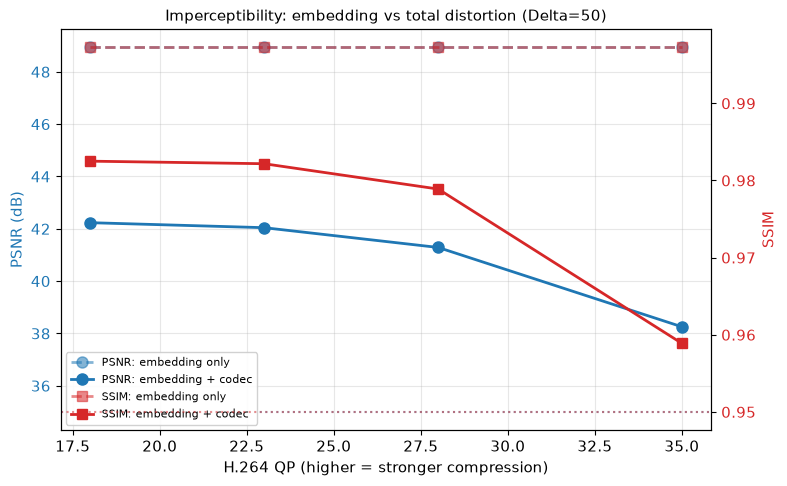

Saved: figure_psnr_ssim.png


In [13]:
# ── Figure 1: imperceptibility, both stages ─────────────────────────
# Two curves answering two questions. Pre-compression isolates DCT-QIM
# distortion and is flat across QP by construction — plotted so that the
# flatness is EXPLAINED rather than looking like a broken experiment.
# Post-compression is cover vs decoded stego: what a warden receives.
if qp_results:
    ok = [r for r in qp_results if r.get('avg_psnr') is not None]
    qps   = [r['qp'] for r in ok]
    pre_p = [r['avg_psnr'] for r in ok]
    pst_p = [r.get('post_psnr', np.nan) for r in ok]
    pre_s = [r['avg_ssim'] for r in ok]
    pst_s = [r.get('post_ssim', np.nan) for r in ok]

    fig, ax1 = plt.subplots(figsize=(8, 5))
    c1, c2 = 'tab:blue', 'tab:red'
    ax1.set_xlabel('H.264 QP (higher = stronger compression)')
    ax1.set_ylabel('PSNR (dB)', color=c1)
    ax1.plot(qps, pre_p, 'o--', color=c1, lw=2, ms=8, alpha=0.55,
             label='PSNR: embedding only')
    ax1.plot(qps, pst_p, 'o-', color=c1, lw=2, ms=8,
             label='PSNR: embedding + codec')
    ax1.axhline(35, color=c1, ls=':', alpha=0.5)
    ax1.tick_params(axis='y', labelcolor=c1)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.set_ylabel('SSIM', color=c2)
    ax2.plot(qps, pre_s, 's--', color=c2, lw=2, ms=7, alpha=0.55,
             label='SSIM: embedding only')
    ax2.plot(qps, pst_s, 's-', color=c2, lw=2, ms=7,
             label='SSIM: embedding + codec')
    ax2.axhline(0.95, color=c2, ls=':', alpha=0.5)
    ax2.tick_params(axis='y', labelcolor=c2)

    hh = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    ll = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(hh, ll, loc='lower left', fontsize=8, framealpha=0.9)

    plt.title(f'Imperceptibility: embedding vs total distortion '
              f'(Delta={QIM_DELTA})', fontsize=11)
    fig.tight_layout()
    plt.savefig(FIG_PSNR_SSIM, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_PSNR_SSIM}")

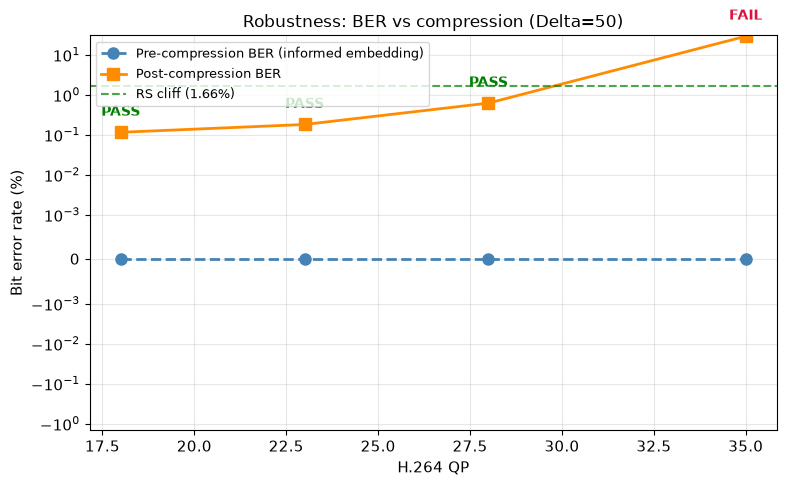

Saved: figure_ber_vs_qp.png


In [14]:
# ── Figure 2: BER vs QP (headline) ──────────────────────────────────
if qp_results:
    ok = [r for r in qp_results if r.get('post_ber') is not None]
    qps  = [r['qp'] for r in ok]
    pre  = [r['pre_ber'] for r in ok]
    post = [r['post_ber'] for r in ok]
    dec  = [r['decryption_ok'] for r in ok]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(qps, pre,  'o--', color='steelblue', lw=2, ms=8,
            label='Pre-compression BER (informed embedding)')
    ax.plot(qps, post, 's-',  color='darkorange', lw=2, ms=8,
            label='Post-compression BER')
    ax.axhline(BER_CLIFF_PCT, color='green', ls='--', alpha=0.7,
               label=f'RS cliff ({BER_CLIFF_PCT:.2f}%)')
    for x, y, d in zip(qps, post, dec):
        ax.annotate('PASS' if d else 'FAIL', (x, y),
                    textcoords='offset points', xytext=(0, 12), ha='center',
                    fontsize=10, fontweight='bold',
                    color='green' if d else 'crimson')
    ax.set_yscale('symlog', linthresh=1e-3)
    ax.set_xlabel('H.264 QP')
    ax.set_ylabel('Bit error rate (%)')
    ax.set_title(f'Robustness: BER vs compression (Delta={QIM_DELTA})',
                 fontsize=12)
    ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_BER_VS_QP, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_BER_VS_QP}")

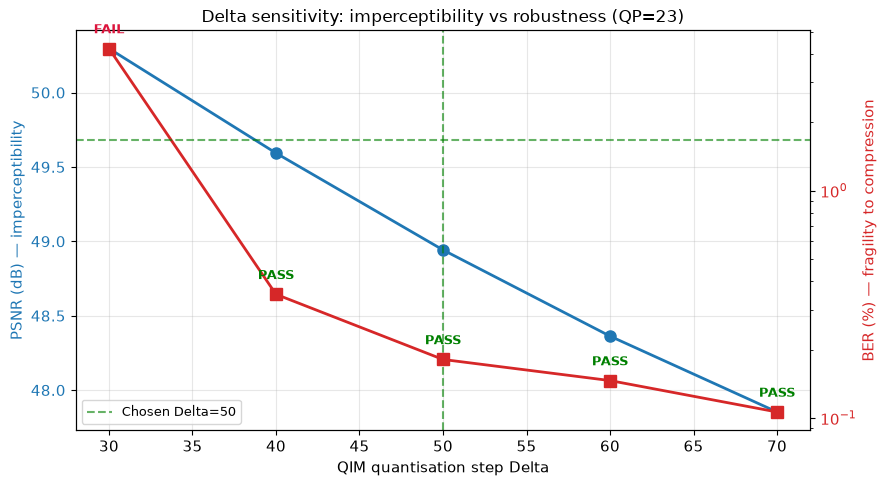

Saved: figure_delta_sweep.png


In [15]:
# ── Figure 3: Delta sensitivity (imperceptibility vs robustness) ────
if delta_results:
    ok = [r for r in delta_results if r.get('post_ber') is not None]
    ds  = [r['delta'] for r in ok]
    ps  = [r['avg_psnr'] for r in ok]
    bs  = [max(r['post_ber'], 1e-3) for r in ok]
    dec = [r['decryption_ok'] for r in ok]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    c1, c2 = 'tab:blue', 'tab:red'
    ax1.plot(ds, ps, 'o-', color=c1, lw=2, ms=8)
    ax1.set_xlabel('QIM quantisation step Delta')
    ax1.set_ylabel('PSNR (dB) — imperceptibility', color=c1)
    ax1.tick_params(axis='y', labelcolor=c1)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(ds, bs, 's-', color=c2, lw=2, ms=8)
    ax2.axhline(BER_CLIFF_PCT, color='green', ls='--', alpha=0.6)
    ax2.set_yscale('log')
    ax2.set_ylabel('BER (%) — fragility to compression', color=c2)
    ax2.tick_params(axis='y', labelcolor=c2)

    for x, y, d in zip(ds, bs, dec):
        ax2.annotate('PASS' if d else 'FAIL', (x, y),
                     textcoords='offset points', xytext=(0, 11), ha='center',
                     fontsize=9, fontweight='bold',
                     color='green' if d else 'crimson')
    ax1.axvline(QIM_DELTA, color='green', ls='--', alpha=0.6,
                label=f'Chosen Delta={QIM_DELTA}')
    ax1.legend(loc='lower left', fontsize=9)
    plt.title(f'Delta sensitivity: imperceptibility vs robustness '
              f'(QP={BASELINE_QP})', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DELTA_SWEEP, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DELTA_SWEEP}")

Generating visual quality grid...


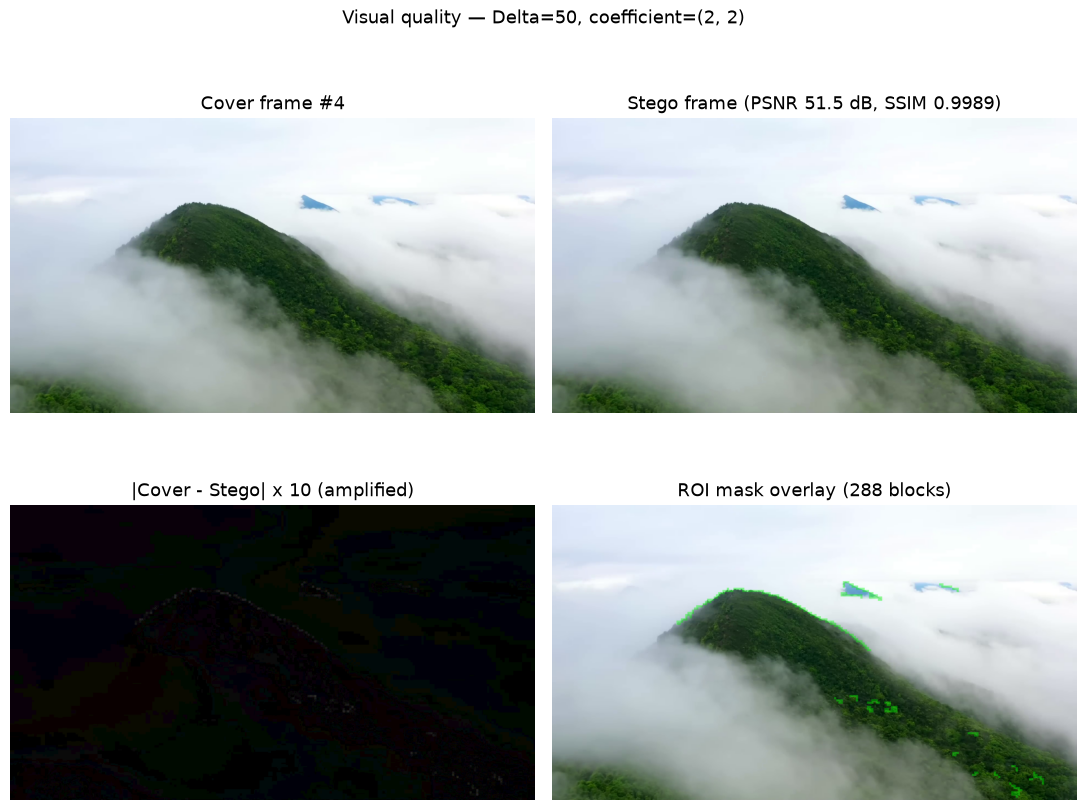

Saved: figure_quality_grid.png


In [16]:
# ── Figure 4: visual quality grid ───────────────────────────────────
# The demo frame is chosen as the one with the MOST ROI blocks among the
# first few, not frame 0 — in many clips frame 0 is atypically smooth and
# would misrepresent the embedding.
print("Generating visual quality grid...")
N_DEMO = 5
stego_demo, bit_idx = [], 0
for i, frame in enumerate(cover_frames[:N_DEMO]):
    if bit_idx >= len(payload_bits):
        stego_demo.append(frame.copy()); continue
    sf, bit_idx, _ = embed_in_frame(frame, roi_masks[i], payload_bits, bit_idx,
                                    BLOCK_SIZE, COEFF_POS, QIM_DELTA)
    stego_demo.append(sf)

demo_idx = int(np.argmax([int(roi_masks[i].sum())
                          for i in range(len(stego_demo))]))
cover_demo, sf_demo = cover_frames[demo_idx], stego_demo[demo_idx]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes[0, 0].imshow(cv2.cvtColor(cover_demo, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f'Cover frame #{demo_idx}'); axes[0, 0].axis('off')

p = calculate_psnr(cover_demo, sf_demo); s = calculate_ssim(cover_demo, sf_demo)
axes[0, 1].imshow(cv2.cvtColor(sf_demo, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Stego frame (PSNR {p:.1f} dB, SSIM {s:.4f})')
axes[0, 1].axis('off')

AMP = 10
diff = np.abs(cover_demo.astype(np.float64) - sf_demo.astype(np.float64))
axes[1, 0].imshow(cv2.cvtColor(np.clip(diff * AMP, 0, 255).astype(np.uint8),
                               cv2.COLOR_BGR2RGB))
axes[1, 0].set_title(f'|Cover - Stego| x {AMP} (amplified)')
axes[1, 0].axis('off')

mp = np.repeat(np.repeat(roi_masks[demo_idx], BLOCK_SIZE, 0), BLOCK_SIZE, 1)
mp = mp[:cover_demo.shape[0], :cover_demo.shape[1]]
ov = cover_demo.copy(); ov[mp == 1] = (0, 255, 0)
axes[1, 1].imshow(cv2.cvtColor(cv2.addWeighted(cover_demo, 0.6, ov, 0.4, 0),
                               cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'ROI mask overlay '
                     f'({int(roi_masks[demo_idx].sum()):,} blocks)')
axes[1, 1].axis('off')

plt.suptitle(f'Visual quality — Delta={QIM_DELTA}, coefficient={COEFF_POS}',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_QUALITY_GRID, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_QUALITY_GRID}")

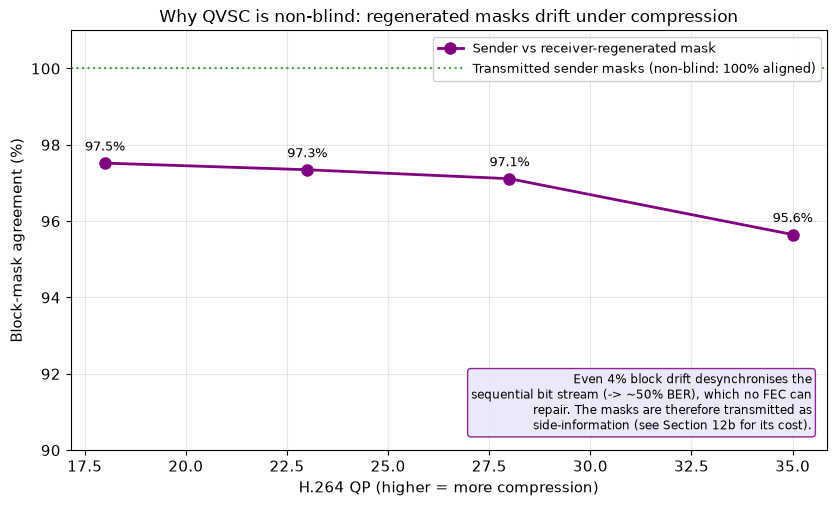

Saved: figure_mask_agreement.png


In [17]:
# ── Figure 5: mask drift — why QVSC must be non-blind ───────────────
# Diagnostic only: extraction uses transmitted sender masks, so this curve
# does not affect BER. It quantifies how far receiver-regenerated masks
# drift under compression, which is the justification for transmitting them.
if qp_results:
    qa = [r for r in qp_results if r.get('mask_agreement') is not None]
    if qa:
        qps   = [r['qp'] for r in qa]
        agree = [r['mask_agreement'] for r in qa]

        fig, ax = plt.subplots(figsize=(8.5, 5.2))
        ax.plot(qps, agree, 'o-', color='purple', lw=2, ms=8,
                label='Sender vs receiver-regenerated mask')
        ax.axhline(100, color='green', ls=':', alpha=0.7,
                   label='Transmitted sender masks (non-blind: 100% aligned)')
        for x, y in zip(qps, agree):
            ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                        xytext=(0, 9), ha='center', fontsize=9)

        ax.set_ylim(min(90.0, min(agree) - 2), 101)
        ax.set_xlabel('H.264 QP (higher = more compression)')
        ax.set_ylabel('Block-mask agreement (%)')
        ax.set_title('Why QVSC is non-blind: regenerated masks drift '
                     'under compression', fontsize=12)
        ax.grid(True, alpha=0.3)
        # Legend upper-right, annotation lower-right — in an earlier version
        # both sat in the lower-right corner and overlapped.
        ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
        ax.text(0.98, 0.04,
                f'Even {100 - min(agree):.0f}% block drift desynchronises the\n'
                f'sequential bit stream (-> ~50% BER), which no FEC can\n'
                f'repair. The masks are therefore transmitted as\n'
                f'side-information (see Section 12b for its cost).',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round', fc='lavender', ec='purple',
                          alpha=0.85))
        plt.tight_layout()
        plt.savefig(FIG_MASK_AGREE, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {FIG_MASK_AGREE}")

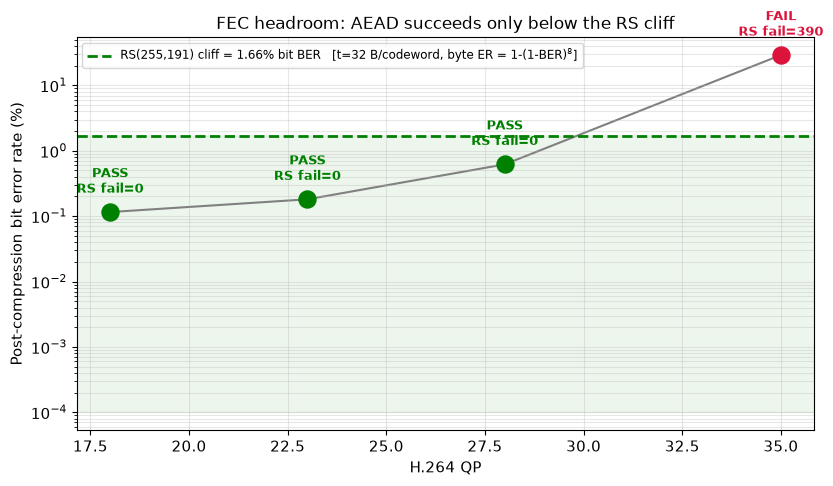


  390 codewords, t=32, cliff=1.66% bit BER

    QP   bit BER%   byte ER%  predicted  observed
  -----------------------------------------------
    18     0.1155      0.920        0.0         0
    23     0.1810      1.439        0.0         0
    28     0.6194      4.849        0.0         0
    35    29.0915     93.609      390.0       390

  Saved: figure_fec_headroom.png


In [18]:
# ── Figure 6: FEC headroom in the bit domain ────────────────────────
# The band and threshold come from BER_CLIFF_PCT (Section 5b), not from a
# byte-domain budget. Comparing bit BER against t/N directly is an 8x
# units error and makes failing configurations look safe.
if qp_results:
    qf = [r for r in qp_results if r.get('post_ber') is not None]
    if qf:
        qps   = [r['qp'] for r in qf]
        bers  = [max(r['post_ber'], 1e-4) for r in qf]
        oks   = [r['decryption_ok'] for r in qf]
        fails = [r.get('fec_fails') for r in qf]

        fig, ax = plt.subplots(figsize=(8.5, 5))
        ax.axhspan(1e-4, BER_CLIFF_PCT, color='green', alpha=0.07)
        ax.axhline(BER_CLIFF_PCT, color='green', ls='--', lw=2,
                   label=(f'RS({fec.RS_N},{fec.RS_K}) cliff = '
                          f'{BER_CLIFF_PCT:.2f}% bit BER   '
                          f'[t={RS_T} B/codeword, byte ER = 1-(1-BER)$^8$]'))
        ax.plot(qps, bers, '-', color='gray', lw=1.5, zorder=1)
        for x, y, ok, fl in zip(qps, bers, oks, fails):
            col = 'green' if ok else 'crimson'
            ax.scatter([x], [y], s=150, color=col, zorder=3)
            ax.annotate(f"{'PASS' if ok else 'FAIL'}\nRS fail={fl}", (x, y),
                        textcoords='offset points', xytext=(0, 14),
                        ha='center', fontsize=9, fontweight='bold', color=col)
        ax.set_yscale('log')
        ax.set_xlabel('H.264 QP')
        ax.set_ylabel('Post-compression bit error rate (%)')
        ax.set_title('FEC headroom: AEAD succeeds only below the RS cliff',
                     fontsize=12)
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(loc='upper left', fontsize=8.5)
        plt.tight_layout()
        plt.savefig(FIG_FEC_HEADROOM, dpi=300, bbox_inches='tight')
        plt.show()

        # ── Predicted vs observed codeword failures ──────────────────
        # Independent-bit-error model: a codeword fails when more than
        # RS_T of its RS_N bytes are corrupt. Agreement between this
        # a-priori model and the measurements is the strongest evidence
        # that the results are real rather than harness artefacts — and
        # it is what justifies the parity choice by analysis rather than
        # by trial and error.
        print(f"\n  {N_CODEWORDS} codewords, t={RS_T}, "
              f"cliff={BER_CLIFF_PCT:.2f}% bit BER\n")
        print(f"  {'QP':>4} {'bit BER%':>10} {'byte ER%':>10} "
              f"{'predicted':>10} {'observed':>9}")
        print("  " + "-" * 47)
        for r in qf:
            pb   = r['post_ber'] / 100.0
            pB   = 1.0 - (1.0 - pb) ** 8
            pred = (1.0 - binom.cdf(RS_T, fec.RS_N, pB)) * N_CODEWORDS
            print(f"  {r['qp']:>4} {r['post_ber']:>10.4f} {pB * 100:>10.3f} "
                  f"{pred:>10.1f} {str(r.get('fec_fails')):>9}")
        print(f"\n  Saved: {FIG_FEC_HEADROOM}")

## Section 11 — Capacity analysis

Capacity is summed over **every** frame. Extrapolating from a single
frame is unsafe: ROI density varies by more than an order of magnitude
across a clip, so any one frame is a poor estimator.

`block_edge_density` is computed once per frame and thresholded at each
level, rather than running Canny once per (frame, threshold) pair.

Computing per-block edge density for all frames...
  425 frames in 9.9s

  threshold=0.10 ->  4,582,465 blocks (mean  10782.3/frame, range 351-21,763) =   572,808 B
  threshold=0.20 ->  4,292,072 blocks (mean  10099.0/frame, range 298-20,666) =   536,509 B
  threshold=0.30 ->  3,977,980 blocks (mean   9360.0/frame, range 254-19,421) =   497,247 B
  threshold=0.40 ->  3,699,571 blocks (mean   8704.9/frame, range 215-18,289) =   462,446 B
  threshold=0.50 ->  3,372,467 blocks (mean   7935.2/frame, range 181-16,933) =   421,558 B
  threshold=0.60 ->  3,087,426 blocks (mean   7264.5/frame, range 147-15,706) =   385,928 B


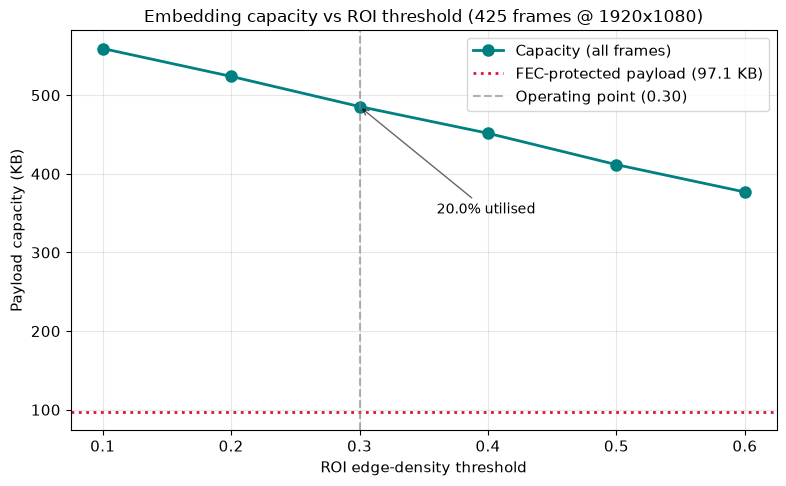


  Operating point 0.3: 497,247 B capacity, 99,450 B payload = 20.0% utilised
  Cross-check: recomputed 3,977,980 blocks vs 3,977,980 in roi_masks.npy  (MATCH)
  Saved: figure_capacity.png


In [19]:
edge_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
if EDGE_THRESHOLD not in edge_thresholds:
    edge_thresholds = sorted(edge_thresholds + [EDGE_THRESHOLD])

print("Computing per-block edge density for all frames...")
_t0 = time.time()
densities = [block_edge_density(f, BLOCK_SIZE) for f in cover_frames]
print(f"  {len(densities)} frames in {time.time() - _t0:.1f}s\n")

capacity_data = []
for th in edge_thresholds:
    per_frame = [int((d > th).sum()) for d in densities]
    total     = int(sum(per_frame))
    capacity_data.append({
        'edge_threshold':   th,
        'roi_blocks_total': total,
        'roi_blocks_mean':  float(np.mean(per_frame)),
        'roi_blocks_min':   int(np.min(per_frame)),
        'roi_blocks_max':   int(np.max(per_frame)),
        'bits_per_video':   total,
        'bytes_per_video':  total // 8,
    })
    print(f"  threshold={th:.2f} -> {total:10,d} blocks "
          f"(mean {np.mean(per_frame):8.1f}/frame, "
          f"range {np.min(per_frame):,}-{np.max(per_frame):,}) "
          f"= {total // 8:9,d} B")

cap_df = pd.DataFrame(capacity_data)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cap_df['edge_threshold'], cap_df['bytes_per_video'] / 1024,
        'o-', lw=2, ms=8, color='teal', label='Capacity (all frames)')
ax.axhline(N_FEC_BYTES / 1024, color='crimson', ls=':', lw=2,
           label=f'FEC-protected payload ({N_FEC_BYTES / 1024:.1f} KB)')
ax.axvline(EDGE_THRESHOLD, color='gray', ls='--', alpha=0.6,
           label=f'Operating point ({EDGE_THRESHOLD:.2f})')

op = cap_df[np.isclose(cap_df['edge_threshold'], EDGE_THRESHOLD)].iloc[0]
ax.annotate(f'{UTILISATION_PCT:.1f}% utilised',
            xy=(EDGE_THRESHOLD, op['bytes_per_video'] / 1024),
            xytext=(EDGE_THRESHOLD + 0.06, op['bytes_per_video'] / 1024 * 0.72),
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.6),
            fontsize=10)

ax.set_xlabel('ROI edge-density threshold')
ax.set_ylabel('Payload capacity (KB)')
ax.set_title(f'Embedding capacity vs ROI threshold '
             f'({len(cover_frames)} frames @ {w}x{h})', fontsize=12)
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(FIG_CAPACITY, dpi=300, bbox_inches='tight')
plt.show()

# Cross-check against the loaded mask array rather than a number copied
# from a previous Module 3 run.
recomputed = int(op['roi_blocks_total'])
print(f"\n  Operating point {EDGE_THRESHOLD}: "
      f"{int(op['bytes_per_video']):,} B capacity, {N_FEC_BYTES:,} B payload "
      f"= {UTILISATION_PCT:.1f}% utilised")
print(f"  Cross-check: recomputed {recomputed:,} blocks vs "
      f"{TOTAL_ROI_BLOCKS:,} in {ROI_MASKS_FILE}  "
      f"({'MATCH' if recomputed == TOTAL_ROI_BLOCKS else 'MISMATCH'})")
if recomputed != TOTAL_ROI_BLOCKS:
    print("  -> Module 3 used different ROI parameters than Section 2. "
          "Reconcile before reporting capacity.")
print(f"  Saved: {FIG_CAPACITY}")

## Section 12 — Results summary

In [20]:
print("=" * 78)
print("  QVSC BENCHMARK SUMMARY")
print("=" * 78)
print(f"  Cover video:      {len(cover_frames)} frames @ {w}x{h} "
      f"@ {VIDEO_FPS:.1f} fps")
print(f"  Embedding:        Y-channel DCT-QIM, coeff {COEFF_POS}, "
      f"Delta={QIM_DELTA}")
print(f"  FEC:              RS({fec.RS_N},{fec.RS_K}) + block interleaving "
      f"({FEC_EXPANSION:.3f}x)")
print(f"  AEAD:             ChaCha20-Poly1305, AAD={AAD.decode()}")
print(f"  Extraction:       non-blind (sender masks transmitted)")
print(f"  Message:          {N_PLAINTEXT:,} B plaintext -> "
      f"{N_FEC_BYTES:,} B embedded")
print(f"  Capacity used:    {UTILISATION_PCT:.1f}% of {CAPACITY_BYTES:,} B")
print("-" * 78)

_ok = [r for r in qp_results if r.get('decryption_ok')]
if _ok:
    b = min(_ok, key=lambda r: abs(r['qp'] - BASELINE_QP))
    _ma = [r['mask_agreement'] for r in qp_results if r.get('mask_agreement')]
    print(f"  Byte-exact through:  QP <= {max(r['qp'] for r in _ok)}")
    print(f"  At QP={b['qp']}:  PSNR {b['avg_psnr']:.2f} dB (embedding), "
          f"{b['post_psnr']:.2f} dB (with codec)")
    print(f"            SSIM {b['avg_ssim']:.4f}, "
          f"post-compression BER {b['post_ber']:.4f}%")
    print(f"            RS codeword failures: {b['fec_fails']} "
          f"of {N_CODEWORDS}")
    print(f"  RS cliff:            {BER_CLIFF_PCT:.2f}% bit BER")
    print(f"  Mask drift:          {np.mean(_ma):.2f}% mean agreement "
          f"-> non-blind extraction required")
else:
    print("  No passing configuration — investigate before writing up.")
print("=" * 78)

  QVSC BENCHMARK SUMMARY
  Cover video:      425 frames @ 1920x1080 @ 30.0 fps
  Embedding:        Y-channel DCT-QIM, coeff (2, 2), Delta=50
  FEC:              RS(255,191) + block interleaving (1.336x)
  AEAD:             ChaCha20-Poly1305, AAD=QVSC-Module2
  Extraction:       non-blind (sender masks transmitted)
  Message:          74,421 B plaintext -> 99,450 B embedded
  Capacity used:    20.0% of 497,247 B
------------------------------------------------------------------------------
  Byte-exact through:  QP <= 28
  At QP=23:  PSNR 48.94 dB (embedding), 42.04 dB (with codec)
            SSIM 0.9973, post-compression BER 0.1810%
            RS codeword failures: 0 of 390
  RS cliff:            1.66% bit BER
  Mask drift:          96.91% mean agreement -> non-blind extraction required


## Section 12b — Side-information cost

Non-blind extraction requires the receiver to hold the sender's ROI
masks. A reviewer will ask the obvious question: *if a channel capable of
delivering that much side information already exists, why not send the
message over it and skip the steganography?*

This must be answered with a measured number, not avoided. Binary masks
are highly compressible, so report the compressed figure — and state the
total the receiver must obtain relative to the message size.

In [21]:
raw_masks = np.packbits(roi_masks.astype(np.uint8)).tobytes()
gz_masks  = gzip.compress(raw_masks, 9)
xz_masks  = lzma.compress(raw_masks, preset=9)
best      = min(len(gz_masks), len(xz_masks))

print("=" * 70)
print("  SIDE-INFORMATION COST OF NON-BLIND EXTRACTION")
print("=" * 70)
print(f"  ROI masks, raw:      {len(raw_masks):>12,} B  "
      f"({len(raw_masks) / 1024 / 1024:.2f} MB)")
print(f"  ROI masks, gzip -9:  {len(gz_masks):>12,} B  "
      f"({len(raw_masks) / len(gz_masks):.1f}x compression)")
print(f"  ROI masks, lzma -9:  {len(xz_masks):>12,} B  "
      f"({len(raw_masks) / len(xz_masks):.1f}x compression)")
print("-" * 70)
print(f"  Plaintext message:   {N_PLAINTEXT:>12,} B")
print(f"  Embedded payload:    {N_FEC_BYTES:>12,} B")
print(f"  Masks (best):        {best:>12,} B  "
      f"= {best / N_PLAINTEXT:.2f}x the message")
print("-" * 70)
print(f"  Receiver must obtain {(best + N_FEC_BYTES) / 1024:>10,.0f} KB total "
      f"to recover {N_PLAINTEXT / 1024:.0f} KB")
print(f"  Overall efficiency:  "
      f"{100 * N_PLAINTEXT / (best + N_FEC_BYTES):>10.1f}%")
print("=" * 70)
print("\n  Report this honestly. The mitigation is key-derived block")
print("  selection: seed a CSPRNG from the shared quantum key so both")
print("  parties compute the same mask with zero side information, at")
print("  the cost of losing content adaptivity.")

np.save('side_information_report.npy', {
    'masks_raw': len(raw_masks), 'masks_gzip': len(gz_masks),
    'masks_lzma': len(xz_masks), 'plaintext': N_PLAINTEXT,
    'fec_payload': N_FEC_BYTES,
    'efficiency_pct': 100 * N_PLAINTEXT / (best + N_FEC_BYTES)})
print("\n  Saved: side_information_report.npy")

  SIDE-INFORMATION COST OF NON-BLIND EXTRACTION
  ROI masks, raw:         1,721,250 B  (1.64 MB)
  ROI masks, gzip -9:       513,737 B  (3.4x compression)
  ROI masks, lzma -9:       345,672 B  (5.0x compression)
----------------------------------------------------------------------
  Plaintext message:         74,421 B
  Embedded payload:          99,450 B
  Masks (best):             345,672 B  = 4.64x the message
----------------------------------------------------------------------
  Receiver must obtain        435 KB total to recover 73 KB
  Overall efficiency:        16.7%

  Report this honestly. The mitigation is key-derived block
  selection: seed a CSPRNG from the shared quantum key so both
  parties compute the same mask with zero side information, at
  the cost of losing content adaptivity.

  Saved: side_information_report.npy


## Section 13 — Steganalysis

PSNR and SSIM establish **perceptual** invisibility only. They say
nothing about **statistical** detectability, which is the actual security
property of a steganographic system.

`qim_embed_bit` forces the target coefficient to `Δ·round(c/Δ) ± Δ/4`, so
every embedded coefficient lands on one of two cosets spaced Δ/2 apart,
producing a comb in the histogram. Natural DCT coefficients are smooth
and roughly Laplacian. That contrast is the signature a detector exploits.

**Expect detectability.** Report it. An honest negative result with a
named mechanism is worth more than a missing section, and it converts
directly into the strongest future-work item.

The split is **grouped by frame**: a plain random split can place a
frame's cover version in train and its stego version in test, letting the
classifier key on frame identity rather than the QIM signature.

Requires `pip install scikit-learn`.

Building stego video at QP=23 for steganalysis...
  150 embedded frames available.

  Coefficients pooled: 492,009 cover / 492,009 stego
  KL(stego || cover)   = 0.5980 nats
  Chi-square statistic = 629,754.2  (dof = 63)
  Grouped split: 105 train frames, 45 test frames (disjoint)

  Detector AUC      = 1.0000   (0.50 = undetectable)
  Detector accuracy = 100.0%  (90 held-out samples)


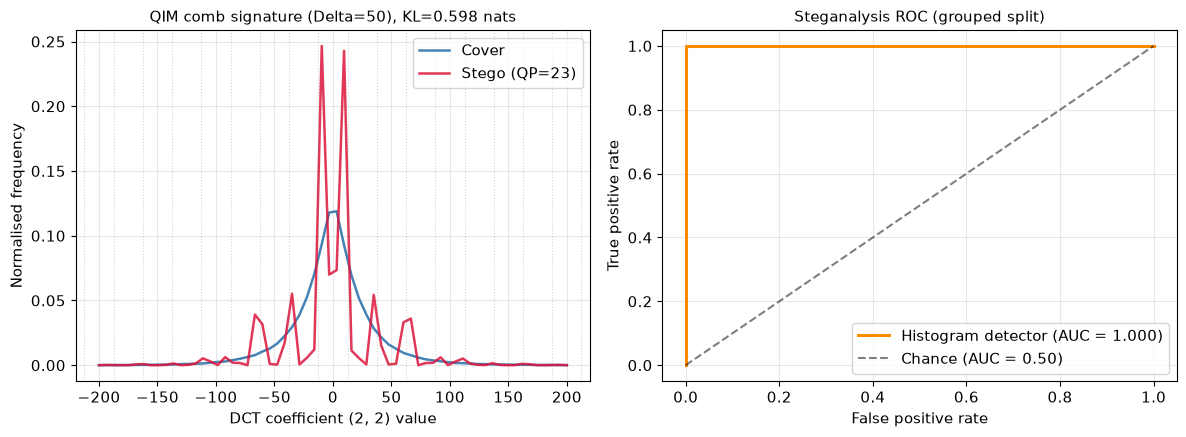


  Saved: figure_steganalysis.png, steganalysis_report.npy


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

STEG_N_FRAMES = 150          # per class; lower to 60 if memory is tight
HIST_BINS     = 64
# Range scales with Delta so the comb stays inside the histogram at any
# embedding strength. A fixed +/-200 silently clips once Delta exceeds ~50,
# which would corrupt the features rather than raising an error.
HIST_SPAN     = 4 * QIM_DELTA
HIST_RANGE    = (-HIST_SPAN, HIST_SPAN)


def frame_coeffs(frame_bgr, mask, block_size=8, coeff_pos=(2, 2), channel=0):
    """Target DCT coefficient of every ROI block, vectorised.

    Reshaping to (by, bx, bs, bs) and calling dctn over the last two axes
    is equivalent to the per-block apply_dct_2d() loop (verified to zero
    absolute difference), but runs as one batched transform instead of
    ~10,000 Python iterations per frame.
    """
    chan   = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)[:, :, channel].astype(np.float64)
    by, bx = mask.shape
    tiles  = chan[:by * block_size, :bx * block_size].reshape(
        by, block_size, bx, block_size).transpose(0, 2, 1, 3)
    D = dctn(tiles, type=2, norm='ortho', axes=(2, 3))
    u, v = coeff_pos
    return D[:, :, u, v][mask.astype(bool)]


def hist_feature(coeffs, bins=HIST_BINS, rng=HIST_RANGE):
    hgram, _ = np.histogram(coeffs, bins=bins, range=rng)
    return hgram / max(hgram.sum(), 1)


# ── 1. Build the stego video at the operating point ──────────────────
print(f"Building stego video at QP={BASELINE_QP} for steganalysis...")
_bi, _stego, _bpf = 0, [], []
for f in cover_frames:
    if _bi >= len(payload_bits):
        _stego.append(f.copy()); _bpf.append(0); continue
    s, _bi, n = embed_in_frame(f, roi_masks[len(_stego)], payload_bits, _bi,
                               BLOCK_SIZE, COEFF_POS, QIM_DELTA)
    _stego.append(s); _bpf.append(n)

_raw, _cmp = '_steg_raw.avi', '_steg_cmp.mp4'
write_lossless_avi(_stego, _raw, VIDEO_FPS)
compress_h264_ffmpeg(_raw, _cmp, qp=BASELINE_QP, preset=H264_PRESET,
                     intra_only=True)
stego_dec, _, _, _ = extract_video_frames(_cmp)

emb_idx = [i for i, n in enumerate(_bpf)
           if n > 0 and i < len(stego_dec)][:STEG_N_FRAMES]
print(f"  {len(emb_idx)} embedded frames available.\n")

# ── 2. Pooled distributions + divergence statistics ──────────────────
cov_all = np.concatenate([frame_coeffs(cover_frames[i], roi_masks[i],
                                       BLOCK_SIZE, COEFF_POS, EMBED_CHANNEL)
                          for i in emb_idx])
stg_all = np.concatenate([frame_coeffs(stego_dec[i], roi_masks[i],
                                       BLOCK_SIZE, COEFF_POS, EMBED_CHANNEL)
                          for i in emb_idx])

p = hist_feature(cov_all) + 1e-12
q = hist_feature(stg_all) + 1e-12
kl = float(entropy(q, p))

c_cnt, _ = np.histogram(cov_all, bins=HIST_BINS, range=HIST_RANGE)
s_cnt, _ = np.histogram(stg_all, bins=HIST_BINS, range=HIST_RANGE)
exp = c_cnt * (s_cnt.sum() / max(c_cnt.sum(), 1)) + 1e-9
chi2_stat = float(((s_cnt - exp) ** 2 / exp).sum())

print(f"  Coefficients pooled: {len(cov_all):,} cover / {len(stg_all):,} stego")
print(f"  KL(stego || cover)   = {kl:.4f} nats")
print(f"  Chi-square statistic = {chi2_stat:,.1f}  (dof = {HIST_BINS - 1})")

# ── 3. Supervised detector, grouped by frame ─────────────────────────
X = np.array([hist_feature(frame_coeffs(cover_frames[i], roi_masks[i],
                                        BLOCK_SIZE, COEFF_POS, EMBED_CHANNEL))
              for i in emb_idx] +
             [hist_feature(frame_coeffs(stego_dec[i], roi_masks[i],
                                        BLOCK_SIZE, COEFF_POS, EMBED_CHANNEL))
              for i in emb_idx])
y      = np.array([0] * len(emb_idx) + [1] * len(emb_idx))
groups = np.array(emb_idx + emb_idx)      # frame index per sample

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
tr_i, te_i = next(gss.split(X, y, groups))
Xtr, Xte, ytr, yte = X[tr_i], X[te_i], y[tr_i], y[te_i]
assert not (set(groups[tr_i]) & set(groups[te_i])), "frame leaked across folds"
print(f"  Grouped split: {len(np.unique(groups[tr_i]))} train frames, "
      f"{len(np.unique(groups[te_i]))} test frames (disjoint)")

sc   = StandardScaler().fit(Xtr)
clf  = LogisticRegression(max_iter=2000).fit(sc.transform(Xtr), ytr)
prob = clf.predict_proba(sc.transform(Xte))[:, 1]
auc  = roc_auc_score(yte, prob)
acc  = clf.score(sc.transform(Xte), yte)

print(f"\n  Detector AUC      = {auc:.4f}   (0.50 = undetectable)")
print(f"  Detector accuracy = {acc * 100:.1f}%  ({len(yte)} held-out samples)")

# ── 4. Figure: comb signature + ROC ──────────────────────────────────
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.5))
ctr = np.linspace(HIST_RANGE[0], HIST_RANGE[1], HIST_BINS)
axA.plot(ctr, p, lw=1.8, color='steelblue', label='Cover')
axA.plot(ctr, q, lw=1.8, color='crimson', alpha=0.85,
         label=f'Stego (QP={BASELINE_QP})')
# QIM forces coefficients to k*Delta +/- Delta/4
for k in range(-(HIST_SPAN // QIM_DELTA), HIST_SPAN // QIM_DELTA + 1):
    for sgn in (+1, -1):
        axA.axvline(k * QIM_DELTA + sgn * QIM_DELTA / 4, color='gray',
                    ls=':', alpha=0.35, lw=0.8)
axA.set_xlabel(f'DCT coefficient {COEFF_POS} value')
axA.set_ylabel('Normalised frequency')
axA.set_title(f'QIM comb signature (Delta={QIM_DELTA}), KL={kl:.3f} nats',
              fontsize=11)
axA.legend(); axA.grid(True, alpha=0.3)

fpr, tpr, _ = roc_curve(yte, prob)
axB.plot(fpr, tpr, lw=2.2, color='darkorange',
         label=f'Histogram detector (AUC = {auc:.3f})')
axB.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Chance (AUC = 0.50)')
axB.set_xlabel('False positive rate'); axB.set_ylabel('True positive rate')
axB.set_title('Steganalysis ROC (grouped split)', fontsize=11)
axB.legend(loc='lower right'); axB.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_STEGANALYSIS, dpi=300, bbox_inches='tight')
plt.show()

for _p in (_raw, _cmp):
    if os.path.exists(_p):
        os.remove(_p)

np.save('steganalysis_report.npy', {
    'kl_divergence': kl, 'chi2': chi2_stat, 'auc': float(auc),
    'accuracy': float(acc), 'n_frames': len(emb_idx),
    'qp': BASELINE_QP, 'delta': QIM_DELTA, 'hist_bins': HIST_BINS,
    'hist_range': HIST_RANGE, 'split': 'GroupShuffleSplit by frame'})
print(f"\n  Saved: {FIG_STEGANALYSIS}, steganalysis_report.npy")

## Section 14 — Ablations and naive baseline

- **A. ROI on/off** — what adaptive masking buys.
- **B. FEC on/off** — AEAD is all-or-nothing, so any residual bit error
  destroys the message. The quantitative form of "FEC is architectural,
  not decorative."
- **C. Spatial LSB baseline** — should be wiped out by H.264, which is
  what makes the DCT-QIM result meaningful.

In [23]:
# ── Ablation A: adaptive ROI vs embed-everywhere ────────────────────
print(f"Ablation A — ROI masking on/off (QP={BASELINE_QP})\n")
abl = []

r_roi = run_pipeline_once(cover_frames, roi_masks, payload_bits,
                          ciphertext_blob, key, qp=BASELINE_QP,
                          delta=QIM_DELTA, coeff_pos=COEFF_POS,
                          block_size=BLOCK_SIZE, preset=H264_PRESET,
                          fps=VIDEO_FPS, edge_threshold=EDGE_THRESHOLD)
abl.append({'config': 'Adaptive ROI (proposed)', **r_roi})

full_masks = np.ones_like(roi_masks)
r_full = run_pipeline_once(cover_frames, full_masks, payload_bits,
                           ciphertext_blob, key, qp=BASELINE_QP,
                           delta=QIM_DELTA, coeff_pos=COEFF_POS,
                           block_size=BLOCK_SIZE, preset=H264_PRESET,
                           fps=VIDEO_FPS, edge_threshold=EDGE_THRESHOLD)
abl.append({'config': 'No ROI (all blocks)', **r_full})

for a in abl:
    if a.get('error'):
        print(f"  {a['config']:<26} ERROR: {a['error']}")
    else:
        print(f"  {a['config']:<26} PSNR={a['avg_psnr']:.2f} dB  "
              f"SSIM={a['avg_ssim']:.4f}  BER={a['post_ber']:.4f}%  "
              f"{'PASS' if a['decryption_ok'] else 'FAIL'}")

Ablation A — ROI masking on/off (QP=23)

  Adaptive ROI (proposed)    PSNR=48.94 dB  SSIM=0.9973  BER=0.1810%  PASS
  No ROI (all blocks)        PSNR=43.23 dB  SSIM=0.9609  BER=6.1052%  FAIL


In [24]:
# ── Ablation B: with and without the FEC layer ──────────────────────
# Without FEC the recovered ciphertext must be bit-exact for Poly1305 to
# verify, so P(success) = (1 - BER)^n over the RAW ciphertext: N_RAW_BITS,
# not N_FEC_BITS, because the no-FEC counterfactual transmits only the
# AEAD blob.
#
# Evaluated in log space. (1-p)**n underflows float64 to exactly 0.0 at
# payloads of this size, which printed "0.000e+00" on every row and
# destroyed the comparison the ablation exists to make.
print("Ablation B — FEC on/off\n")
print(f"  Raw ciphertext:  {N_RAW_BYTES:,} B ({N_RAW_BITS:,} bits)")
print(f"  FEC-protected:   {N_FEC_BYTES:,} B "
      f"({FEC_EXPANSION:.3f}x expansion, {N_CODEWORDS} codewords)\n")
print(f"  {'QP':>4} {'BER%':>10} {'P(success) no FEC':>20} {'with FEC':>10}")
print("  " + "-" * 48)
for r in qp_results:
    if r.get('post_ber') is None:
        continue
    pb = r['post_ber'] / 100.0
    p_str = f"1e{N_RAW_BITS * math.log10(1 - pb):.0f}" if pb > 0 else "1.0"
    print(f"  {r['qp']:>4} {r['post_ber']:>10.4f} {p_str:>20} "
          f"{'PASS' if r['decryption_ok'] else 'FAIL':>10}")
print("\n  Without FEC the scheme succeeds only at BER exactly 0.")
print("  Every non-zero row above is a total loss of the message.")

Ablation B — FEC on/off

  Raw ciphertext:  74,449 B (595,592 bits)
  FEC-protected:   99,450 B (1.336x expansion, 390 codewords)

    QP       BER%    P(success) no FEC   with FEC
  ------------------------------------------------
    18     0.1155               1e-299       PASS
    23     0.1810               1e-469       PASS
    28     0.6194              1e-1607       PASS
    35    29.0915             1e-88923       FAIL

  Without FEC the scheme succeeds only at BER exactly 0.
  Every non-zero row above is a total loss of the message.


In [25]:
# ── Ablation C: spatial-domain LSB baseline ─────────────────────────
# One bit per ROI block (top-left pixel of the block's Y channel) so the
# capacity matches DCT-QIM exactly and the comparison is like for like.
def lsb_embed_frame(frame_bgr, mask, bits, bit_index, block_size=8, channel=0):
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    chan  = ycrcb[:, :, channel]
    by_n, bx_n = mask.shape
    n = 0
    for by in range(by_n):
        for bx in range(bx_n):
            if bit_index >= len(bits): break
            if mask[by, bx] == 0: continue
            y0, x0 = by * block_size, bx * block_size
            chan[y0, x0] = (chan[y0, x0] & 0xFE) | int(bits[bit_index])
            bit_index += 1; n += 1
        if bit_index >= len(bits): break
    ycrcb[:, :, channel] = chan
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR), bit_index, n


def lsb_extract_frame(frame_bgr, mask, n_bits, block_size=8, channel=0):
    chan = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)[:, :, channel]
    by_n, bx_n = mask.shape
    out = []
    for by in range(by_n):
        for bx in range(bx_n):
            if len(out) >= n_bits: break
            if mask[by, bx] == 0: continue
            out.append(int(chan[by * block_size, bx * block_size] & 1))
        if len(out) >= n_bits: break
    return out


print(f"Ablation C — spatial LSB baseline (QP={BASELINE_QP})\n")
_i, lsb_frames, lsb_bpf, lsb_psnr = 0, [], [], []
for f in cover_frames:
    if _i >= len(payload_bits):
        lsb_frames.append(f.copy()); lsb_bpf.append(0); continue
    s, _i, n = lsb_embed_frame(f, roi_masks[len(lsb_frames)], payload_bits,
                               _i, BLOCK_SIZE, EMBED_CHANNEL)
    lsb_frames.append(s); lsb_bpf.append(n)
    if n > 0:
        lsb_psnr.append(calculate_psnr(f, s))

_r, _c = '_lsb_raw.avi', '_lsb_cmp.mp4'
write_lossless_avi(lsb_frames, _r, VIDEO_FPS)
compress_h264_ffmpeg(_r, _c, qp=BASELINE_QP, preset=H264_PRESET,
                     intra_only=True)
lsb_dec, _, _, _ = extract_video_frames(_c)

lb, left = [], len(payload_bits)
for i, fr in enumerate(lsb_dec):
    if left <= 0 or i >= len(lsb_bpf) or lsb_bpf[i] == 0:
        continue
    e = lsb_extract_frame(fr, roi_masks[i], lsb_bpf[i], BLOCK_SIZE,
                          EMBED_CHANNEL)
    lb.extend(e); left -= len(e)
lb = np.array(lb[:len(payload_bits)], dtype=np.uint8)
lsb_ber = float(np.mean(lb != payload_bits[:len(lb)]) * 100)

_qb = next((r for r in qp_results if r['qp'] == BASELINE_QP), None)
print(f"  Spatial LSB:      PSNR={np.mean(lsb_psnr):.2f} dB, "
      f"post-compression BER={lsb_ber:.2f}%")
if _qb and _qb.get('post_ber'):
    print(f"  DCT-QIM (ours):   PSNR={_qb['avg_psnr']:.2f} dB, "
          f"post-compression BER={_qb['post_ber']:.4f}%")
    print(f"\n  BER reduction: {lsb_ber / _qb['post_ber']:,.0f}x")
    print(f"  LSB is at {lsb_ber:.1f}% — chance level is 50%, so the "
          f"payload is destroyed.")

for _p in (_r, _c):
    if os.path.exists(_p):
        os.remove(_p)

pd.DataFrame([{k: v for k, v in a.items()
               if not isinstance(v, (list, np.ndarray))}
              for a in abl]).to_csv('ablation_results.csv', index=False)
print("\n  Saved: ablation_results.csv")

Ablation C — spatial LSB baseline (QP=23)

  Spatial LSB:      PSNR=52.24 dB, post-compression BER=50.01%
  DCT-QIM (ours):   PSNR=48.94 dB, post-compression BER=0.1810%

  BER reduction: 276x
  LSB is at 50.0% — chance level is 50%, so the payload is destroyed.

  Saved: ablation_results.csv


## Section 15 — Multi-video evaluation *(optional)*

Set `RUN_MULTIVIDEO = True` in Section 2 and supply extra clips.

**Design note.** Capacity is a property of the (video, threshold,
payload) triple — all three under our control — not a property of the
video. Silently skipping a low-capacity clip would break the mean ± std
comparison this section exists to produce, so it **fails loudly** instead.
Run the survey cell first to size a payload every clip can carry.

In [26]:
# ── Stage 1: capacity survey (fast — no embedding, no ffmpeg) ───────
VIDEO_PATHS = ['cover_video.mp4', 'cover_video_2.mp4',
               'cover_video_3.mp4', 'cover_video_4.mp4']
SURVEY_THRESHOLDS = (0.15, 0.20, EDGE_THRESHOLD)

if RUN_MULTIVIDEO:
    survey = []
    for vp in VIDEO_PATHS:
        if not os.path.exists(vp):
            print(f"  missing: {vp}"); continue
        fr, _, vw, vh = extract_video_frames(vp)
        dens = [block_edge_density(f, BLOCK_SIZE) for f in fr]
        row = {'video': os.path.basename(vp), 'frames': len(fr),
               'res': f'{vw}x{vh}'}
        for th in SURVEY_THRESHOLDS:
            row[f'bits@{th}'] = int(sum(int((d > th).sum()) for d in dens))
        survey.append(row)

    sv = pd.DataFrame(survey)
    print(sv.to_string(index=False), "\n")
    for th in SURVEY_THRESHOLDS:
        m = sv[f'bits@{th}'].min()
        max_pt = int(m / 8 / FEC_EXPANSION) - NONCE_LEN - TAG_LEN
        print(f"  threshold {th}: min capacity {m:,} bits = {m // 8:,} B "
              f"-> max plaintext ~{max_pt:,} B at {FEC_EXPANSION:.3f}x FEC")
    print(f"\n  Current plaintext is {N_PLAINTEXT:,} B. If that exceeds the "
          f"limit above,\n  shorten the message and re-run Module 2 before "
          f"the sweep.")
else:
    print("  RUN_MULTIVIDEO=False — skipping.")

  RUN_MULTIVIDEO=False — skipping.


In [27]:
# ── Stage 2: sweep across videos ────────────────────────────────────
multi_results = []

if RUN_MULTIVIDEO:
    for vpath in VIDEO_PATHS:
        if not os.path.exists(vpath):
            print(f"  missing: {vpath}"); continue

        print(f"\n{'=' * 70}\n  VIDEO: {vpath}\n{'=' * 70}")
        v_frames, v_fps, vw, vh = extract_video_frames(vpath)
        v_masks = np.stack([detect_roi_blocks(f, BLOCK_SIZE,
                                              edge_threshold=EDGE_THRESHOLD)
                            for f in v_frames])
        cap_bits = int(v_masks.sum())
        print(f"  {len(v_frames)} frames @ {vw}x{vh}, "
              f"capacity {cap_bits:,} bits, payload {N_FEC_BITS:,} bits")

        if cap_bits < N_FEC_BITS:
            raise ValueError(
                f"{vpath}: capacity {cap_bits:,} < payload {N_FEC_BITS:,} "
                f"bits.\nShrink the common payload (re-run Module 2) or lower "
                f"EDGE_THRESHOLD — do not skip, since a partial video set "
                f"invalidates the mean/std comparison.")

        for qp in QP_VALUES:
            r = run_pipeline_once(v_frames, v_masks, payload_bits,
                                  ciphertext_blob, key, qp=qp,
                                  delta=QIM_DELTA, coeff_pos=COEFF_POS,
                                  block_size=BLOCK_SIZE, preset=H264_PRESET,
                                  fps=v_fps, edge_threshold=EDGE_THRESHOLD)
            r['video'] = os.path.basename(vpath)
            multi_results.append(r)
            if r.get('error'):
                print(f"    QP={qp}: ERROR {r['error']}")
            else:
                print(f"    QP={qp}: PSNR={r['avg_psnr']:.2f} dB  "
                      f"BER={r['post_ber']:.4f}%  RSfail={r['fec_fails']}  "
                      f"{'PASS' if r['decryption_ok'] else 'FAIL'}")

    mv = pd.DataFrame([r for r in multi_results if not r.get('error')])
    if not mv.empty:
        agg = mv.groupby('qp').agg(
            n_videos=('video', 'nunique'),
            psnr_mean=('avg_psnr', 'mean'), psnr_std=('avg_psnr', 'std'),
            ssim_mean=('avg_ssim', 'mean'),
            ber_mean=('post_ber', 'mean'), ber_std=('post_ber', 'std'),
            mask_mean=('mask_agreement', 'mean'),
            success_rate=('decryption_ok', 'mean')).reset_index()
        agg['success_rate'] *= 100
        print("\n" + "=" * 70)
        print("  MULTI-VIDEO SUMMARY (mean +/- std across videos)")
        print("=" * 70)
        print(agg.to_string(index=False))
        mv.to_csv('multivideo_results.csv', index=False)
        agg.to_csv('multivideo_summary.csv', index=False)

        fig, ax = plt.subplots(figsize=(8, 5))
        for vid, g in mv.groupby('video'):
            g = g.sort_values('qp')
            ax.plot(g['qp'], g['post_ber'], 'o-', alpha=0.6, lw=1.5, ms=6,
                    label=vid)
        a = agg.sort_values('qp')
        ax.plot(a['qp'], a['ber_mean'], 'k-', lw=3, label='mean', zorder=5)
        ax.fill_between(a['qp'], a['ber_mean'] - a['ber_std'].fillna(0),
                        a['ber_mean'] + a['ber_std'].fillna(0),
                        color='gray', alpha=0.2)
        ax.axhline(BER_CLIFF_PCT, color='green', ls='--', alpha=0.7,
                   label=f'RS cliff ({BER_CLIFF_PCT:.2f}%)')
        ax.set_yscale('log')
        ax.set_xlabel('H.264 QP')
        ax.set_ylabel('Post-compression bit error rate (%)')
        ax.set_title('Robustness across cover videos', fontsize=12)
        ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig('figure_multivideo_ber.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("\n  Saved: multivideo_results.csv, figure_multivideo_ber.png")
else:
    print("  RUN_MULTIVIDEO=False — skipping.")

  RUN_MULTIVIDEO=False — skipping.


## Verification checklist

All expectations are relational, so they hold for any payload, parity, or
cover video.

| Section | Check |
|---|---|
| 5b | `FEC-protected` = `N_CODEWORDS` × `RS_N`, no exception raised |
| 5b | cliff = `1 − (1 − t/N)^(1/8)`, not `t/N` |
| 7 | pre-compression BER `0.0000%` on **every** row — non-zero means informed embedding hit `max_iter` |
| 7 | decryption PASSes exactly while post BER < cliff |
| 10 Fig 1 | post-compression PSNR **declines** with QP (flat ⇒ the metric isn't measuring the codec) |
| 10 Fig 6 | predicted ≈ observed codeword failures |
| 11 | recomputed blocks **MATCH** the loaded mask array |
| 12b | efficiency reported — the answer to "why not send the message directly?" |
| 13 | AUC reported; > 0.5 is a finding, not a failure |
| 14A | no-ROI configuration degrades |
| 14C | LSB BER ≈ 50% (chance) |

Console-only outputs worth saving to a text file: the Section 10 Figure 6
predicted-vs-observed table, the Section 12b efficiency block, and the
Section 14B log-space table.